 50 
'AUGMENTIN' 112 
'Antalfen' 112 
'Betamethasone' 112 
'Bilaxten' 112 
'Bio Mag' 112 
'Biocabastine' 112 
'Bioclav' 112 
'CALMOFEN' 112 
'CELECOXIB' 112 
'CLARITHRO' 112 
'CLOFENAL' 112 
'CURACNE' 116 
'DAFALGAN' 112 
'DAPROSAL' 112 
'DIAMICRON' 112 
'Dermagor' 112 
'Desomedine' 112 
'Diane' 112 
'FAMISIL' 112 
'FRUBIAL' 112 
'Flagyl' 112 
'Fucare' 112 
'GESPASPON' 112 
'GLYCERINE LS' 112 
'Gatifloxacine GL' 112 
'Isomedine' 112 
'KETOCONAZLO' 112 
'LEXINAL' 112 
'LOMAC' 112 
'Lamoxyl' 112 
'LevoSpasmr' 112 
'Lexin' 112 
'MEBO' 112 
'Maxilase' 112 
'Megnol Stress' 112 
'NASACET' 112 
'Normalax' 112 
'Novoformine' 112 
'Obrax' 112 
'PRIMPA' 112 
'Physiomag' 112 
'Rifex' 112 
'SINTOGEL' 112 
'Solyne MAGNESIUM' 112 
'Solyne Zinc' 112 
'TRIMEBUTINE' 112 
'UPSA VITAMINEE C' 112 
'VOGALYS' 112 
'Vavo' 112 
'ZANITRA' 112 
 50 
'AUGMENTIN' 28 
'Antalfen' 28 
'Betamethasone' 28 
'Bilaxten' 28 
'Bio Mag' 28 
'Biocabastine' 28 
'Bioclav' 28 
'CALMOFEN' 28 
'CELECOXIB' 28 
'CLARITHRO' 28 
'CLO

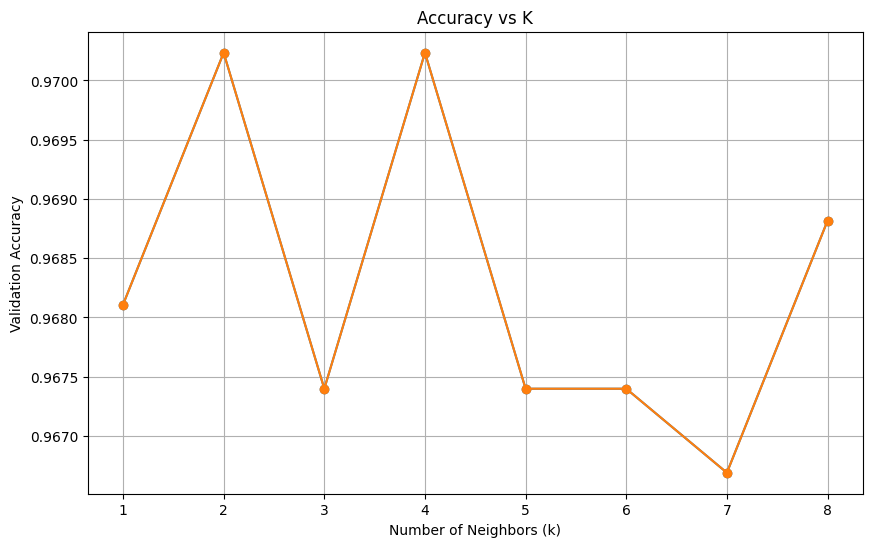

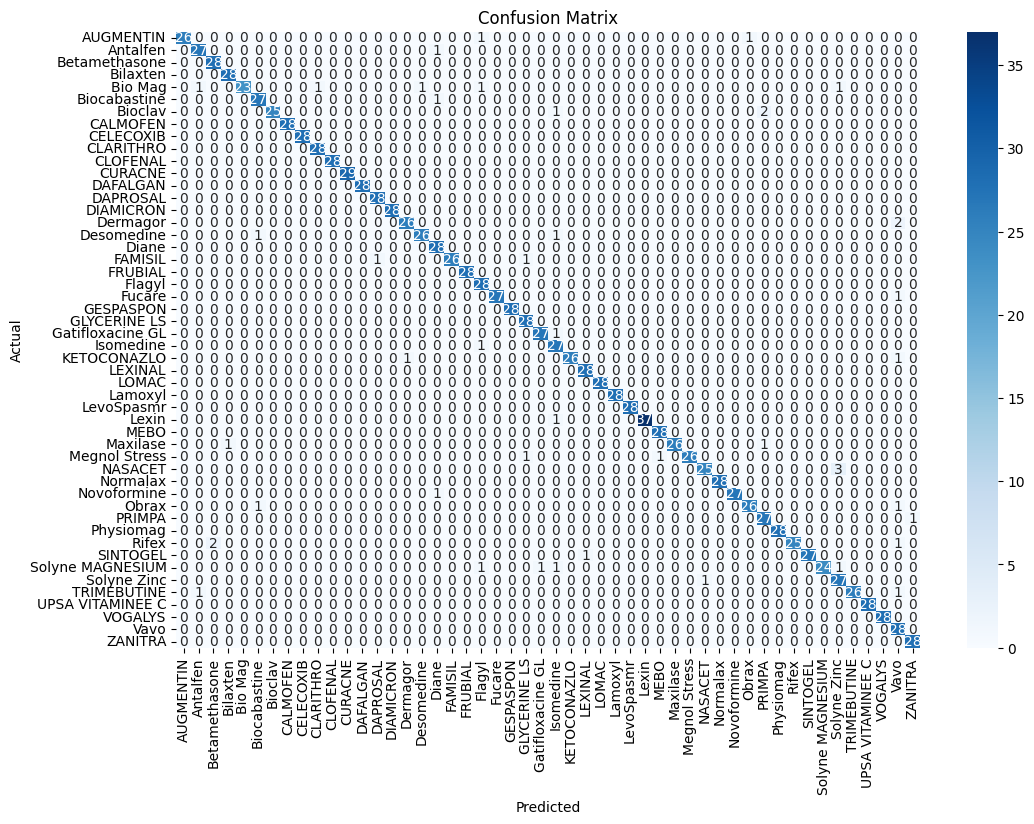

In [26]:
import os
import cv2
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns


def apply_gabor(img):
    g_kernel = cv2.getGaborKernel((21, 21), 8.0, np.pi/4, 10.0, 0.5, 0, ktype=cv2.CV_32F)
    filtered_img = cv2.filter2D(img, cv2.CV_8UC3, g_kernel)
    return filtered_img

def apply_dog(img):
    blur1 = cv2.GaussianBlur(img, (5, 5), 1)
    blur2 = cv2.GaussianBlur(img, (5, 5), 2)
    dog = cv2.subtract(blur1, blur2)
    return dog


def load_and_process_images(base_path):
    data = []
    labels = []
    class_names = sorted([folder for folder in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, folder))])

    print(f" {len(class_names)} ")

    for idx, class_folder in enumerate(class_names):
        class_path = os.path.join(base_path, class_folder)
        image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

        print(f"'{class_folder}' {len(image_files)} ")

        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (128, 128))


            dog_img = apply_dog(img)
            gabor_img = apply_gabor(dog_img)


            data.append(gabor_img.flatten())
            labels.append(idx)

    return np.array(data), np.array(labels), class_names


train_path = '/content/drive/MyDrive/KAdata/train'
val_path = '/content/drive/MyDrive/KAdata/validation'

train_data, train_labels, class_names = load_and_process_images(train_path)
val_data, val_labels, _ = load_and_process_images(val_path)

print(f"Training data size: {len(train_data)}")
print(f" Validation data size: {len(val_data)}")


lda = LinearDiscriminantAnalysis(n_components=min(len(np.unique(train_labels))-1, 50))
train_data_lda = lda.fit_transform(train_data, train_labels)
val_data_lda = lda.transform(val_data)


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_data_lda, train_labels)

val_predictions = knn.predict(val_data_lda)
val_probabilities = knn.predict_proba(val_data_lda)


acc = accuracy_score(val_labels, val_predictions)
print(f"\n Model accuracy : {acc * 100:.2f}%")
loss = log_loss(val_labels, val_probabilities)
print(f"(Log Loss): {loss:.4f}")

print("\n Classification Report:")
from sklearn.utils.multiclass import unique_labels
unique_val_labels = unique_labels(val_labels)
print(classification_report(val_labels, val_predictions, labels=unique_val_labels,
                            target_names=[class_names[i] for i in unique_val_labels]))

accuracies = []
base_K_values = [4]

plt.figure(figsize=(10, 6))

for base_k in base_K_values:
    accuracies = []
    ks = range(1, 9)
for k in ks:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(train_data_lda, train_labels)
        preds = knn.predict(val_data_lda)
        acc = accuracy_score(val_labels, preds)
        accuracies.append(acc)

plt.plot(ks, accuracies, marker='o', label=f"K={base_k} input")
plt.plot(ks, accuracies, marker='o')
plt.title("Accuracy vs K")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.show()


cm = confusion_matrix(val_labels, val_predictions)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[class_names[i] for i in unique_val_labels],
            yticklabels=[class_names[i] for i in unique_val_labels])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

50 class.
class 'AUGMENTIN'  112 image .
class 'Antalfen'  112 image .
class 'Betamethasone'  112 image .
class 'Bilaxten'  112 image .
class 'Bio Mag'  112 image .
class 'Biocabastine'  112 image .
class 'Bioclav'  112 image .
class 'CALMOFEN'  112 image .
class 'CELECOXIB'  112 image .
class 'CLARITHRO'  112 image .
class 'CLOFENAL'  112 image .
class 'CURACNE'  116 image .
class 'DAFALGAN'  112 image .
class 'DAPROSAL'  112 image .
class 'DIAMICRON'  112 image .
class 'Dermagor'  112 image .
class 'Desomedine'  112 image .
class 'Diane'  112 image .
class 'FAMISIL'  112 image .
class 'FRUBIAL'  112 image .
class 'Flagyl'  112 image .
class 'Fucare'  112 image .
class 'GESPASPON'  112 image .
class 'GLYCERINE LS'  112 image .
class 'Gatifloxacine GL'  112 image .
class 'Isomedine'  112 image .
class 'KETOCONAZLO'  112 image .
class 'LEXINAL'  112 image .
class 'LOMAC'  112 image .
class 'Lamoxyl'  112 image .
class 'LevoSpasmr'  112 image .
class 'Lexin'  112 image .
class 'MEBO'  11

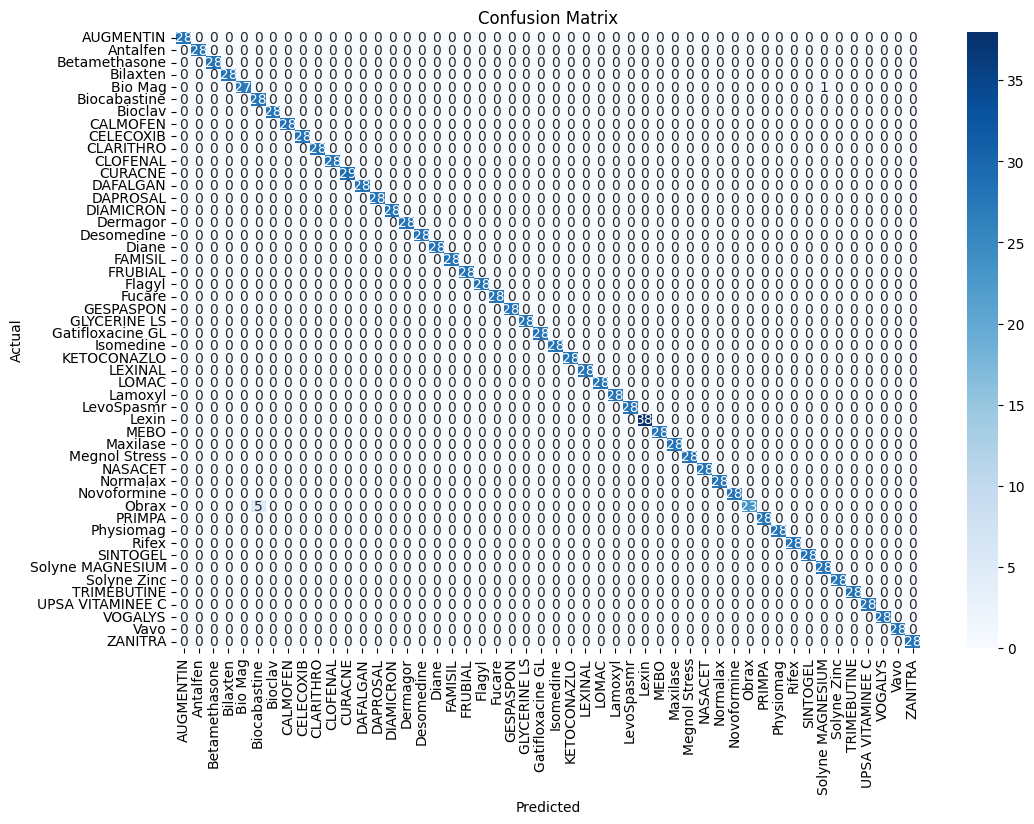

In [22]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog


def load_and_extract_features(base_path):
    data = []
    labels = []
    class_names = sorted([folder for folder in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, folder))])

    print(f"{len(class_names)} class.")

    for idx, class_folder in enumerate(class_names):
        class_path = os.path.join(base_path, class_folder)
        image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

        print(f"class '{class_folder}'  {len(image_files)} image .")

        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, (128, 128))

            features = hog(gray, orientations=6, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), block_norm='L2-Hys')

            data.append(features)
            labels.append(idx)

    return np.array(data), np.array(labels), class_names


train_path = '/content/drive/MyDrive/KAdata/train'
val_path = '/content/drive/MyDrive/KAdata/validation'


train_data, train_labels, class_names = load_and_extract_features(train_path)
val_data, val_labels, _ = load_and_extract_features(val_path)

print(f"\nTraining data size: {train_data.shape}")
print(f"Validation data size : {val_data.shape}")


pca = PCA(n_components=50)
train_data_pca = pca.fit_transform(train_data)
val_data_pca = pca.transform(val_data)



svm = SVC(kernel='rbf', C=1, gamma='auto')
svm.fit(train_data_pca, train_labels)



val_predictions = svm.predict(val_data_pca)


accuracy = accuracy_score(val_labels, val_predictions)
print(f"\nج: {accuracy * 100:.2f}%")


print("\nف:")
print(classification_report(val_labels, val_predictions, target_names=[class_names[i] for i in np.unique(val_labels)]))

cm = confusion_matrix(val_labels, val_predictions)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_names[i] for i in np.unique(val_labels)],
            yticklabels=[class_names[i] for i in np.unique(val_labels)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [24]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from PIL import Image
from torchvision import transforms


def build_gabor_kernels(scales=4, orientations=6):
    kernels = []
    for theta in np.linspace(0, np.pi, orientations, endpoint=False):
        for sigma in (1, 2):
            for lamda in np.linspace(np.pi/4, np.pi, scales):
                kernel = cv2.getGaborKernel((21, 21), sigma, theta, lamda, 0.5, 0, ktype=cv2.CV_32F)
                kernels.append(kernel)
    return kernels


def extract_gabor_features(image, kernels):
    feats = []
    for k in kernels:
        f = cv2.filter2D(image, cv2.CV_8UC3, k)
        feats.append(f.mean())
        feats.append(f.std())
    return feats


augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop((128, 128), scale=(0.8, 1.0))
])

def load_dataset_with_gabor(data_dir, augment_images=False, augment_factor=2):
    X, y = [], []
    kernels = build_gabor_kernels()
    classes = sorted(os.listdir(data_dir))

    for label in classes:
        class_dir = os.path.join(data_dir, label)
        for filename in os.listdir(class_dir):
            path = os.path.join(class_dir, filename)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (128, 128))
            features = extract_gabor_features(img, kernels)
            X.append(features)
            y.append(label)


    return np.array(X), np.array(y), classes

train_path = "/content/drive/MyDrive/KAdata/train"
val_path = "/content/drive/MyDrive/KAdata/validation"


X_train, y_train, classes = load_dataset_with_gabor(train_path, augment_images=True, augment_factor=2)
X_val, y_val, _ = load_dataset_with_gabor(val_path, augment_images=False)


le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)


pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)

svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train_pca, y_train_enc)


y_pred = svm.predict(X_val_pca)
print("📊 Classification Report :\n", classification_report(y_val_enc, y_pred, target_names=le.classes_))
print("🎯 accuracy :", accuracy_score(y_val_enc, y_pred))


📊 Classification Report :
                   precision    recall  f1-score   support

       AUGMENTIN       1.00      1.00      1.00        28
        Antalfen       1.00      1.00      1.00        28
   Betamethasone       1.00      1.00      1.00        28
        Bilaxten       1.00      0.93      0.96        28
         Bio Mag       1.00      1.00      1.00        28
    Biocabastine       0.97      1.00      0.98        28
         Bioclav       1.00      1.00      1.00        28
        CALMOFEN       1.00      1.00      1.00        28
       CELECOXIB       1.00      1.00      1.00        28
       CLARITHRO       1.00      1.00      1.00        28
        CLOFENAL       1.00      1.00      1.00        28
         CURACNE       1.00      1.00      1.00        29
        DAFALGAN       1.00      1.00      1.00        28
        DAPROSAL       1.00      1.00      1.00        28
       DIAMICRON       1.00      1.00      1.00        28
        Dermagor       1.00      0.96      0

🎯 (Accuracy): 0.9936
📌 Precision: 0.994
📌 Recall: 0.9936
📌 F1 Score: 0.9936

(confusion matrix):
 [[28  0  0 ...  0  0  0]
 [ 0 28  0 ...  0  0  0]
 [ 0  0 28 ...  0  0  0]
 ...
 [ 0  0  0 ... 28  0  0]
 [ 0  0  0 ...  0 28  0]
 [ 0  0  0 ...  0  0 28]]


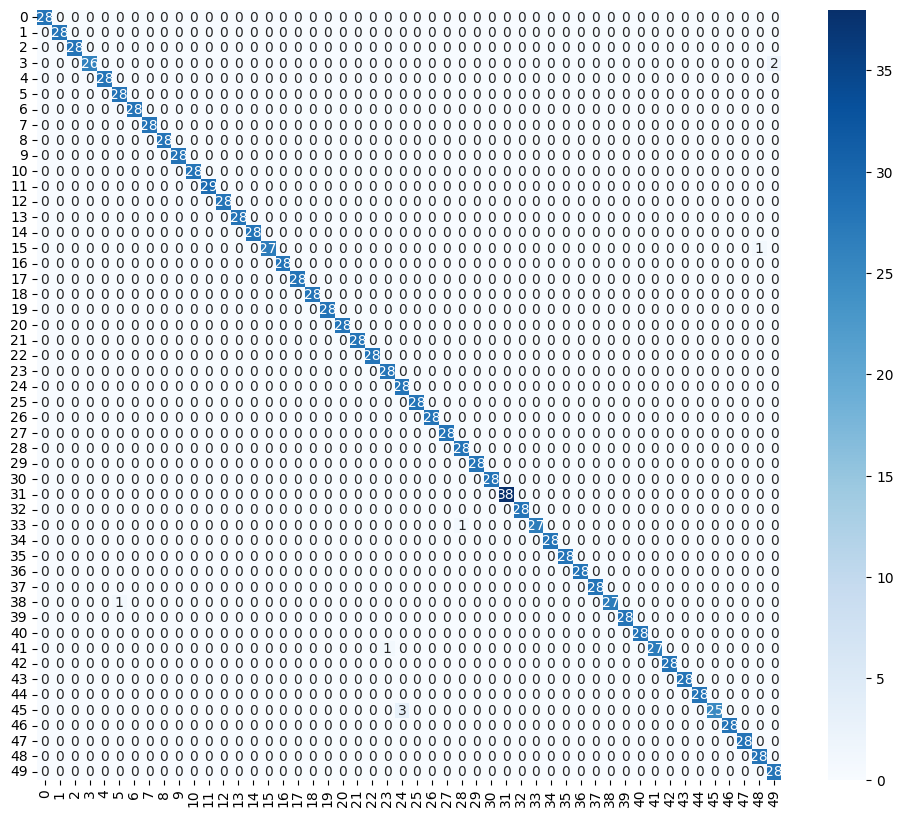

/tmp/ipykernel_2998/2444893422.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette="crest")


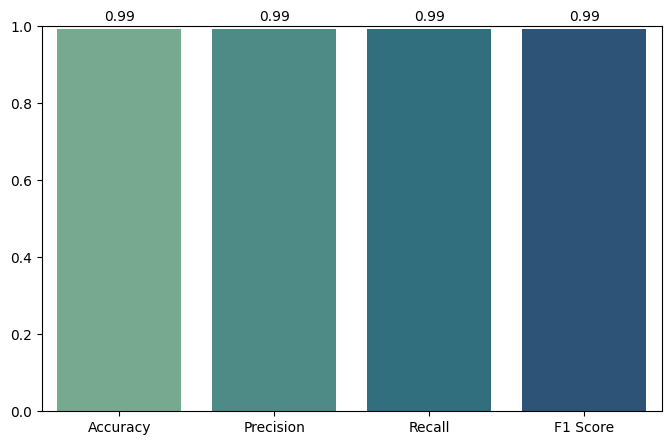

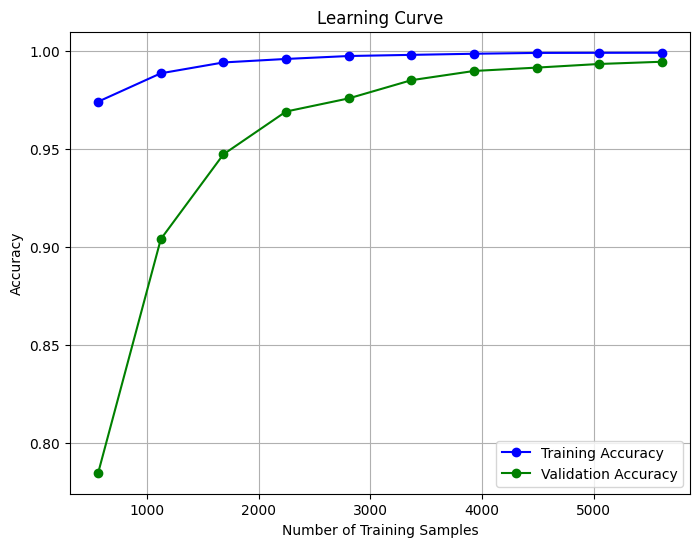

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score
)
from sklearn.model_selection import learning_curve


accuracy = accuracy_score(y_val_enc, y_pred)
precision = precision_score(y_val_enc, y_pred, average='macro')
recall = recall_score(y_val_enc, y_pred, average='macro')
f1 = f1_score(y_val_enc, y_pred, average='macro')

print("🎯 (Accuracy):", round(accuracy, 4))
print("📌 Precision:", round(precision, 4))
print("📌 Recall:", round(recall, 4))
print("📌 F1 Score:", round(f1, 4))


cm = confusion_matrix(y_val_enc, y_pred)
print("\n(confusion matrix):\n", cm)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.show()


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values, palette="crest")
plt.ylim(0, 1)
plt.title("")
plt.ylabel("")
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.show()


train_sizes, train_scores, test_scores = learning_curve(
    svm, np.concatenate((X_train_pca, X_val_pca)),
    np.concatenate((y_train_enc, y_val_enc)),
    cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), shuffle=True, random_state=42
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue',  label='Training Accuracy')
plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Validation Accuracy')
plt.title("Learning Curve")
plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()
